# Why all caches so bad at the cluster012sample?


![Альтернативный текст](../graphics/all/cluster012-plot.png)

Because this dataset does not contain a "Hot Core." It is a massive stream of unique data (scans) in which repetitions appear only sporadically and at vast intervals—on average, every 12,000 to 20,000 requests.

In [1]:
import utils

In [2]:
path = "../2_twitter/cluster012-parsed.txt"

In [3]:
keys = utils.read_keys_sequence(path=path)
print(len(keys))

1000000


In [4]:
keys_frequencies = utils.get_keys_frequencies(keys_sequence=keys)

print(f"Herfindahl Hirschman Index: {utils.cacl_herfindahl_hirschman_index(values=keys)}")

utils.print_sequence_stat(values=keys_frequencies.values())

Herfindahl Hirschman Index: 1.5988300000066518e-06
Max: 19
Min: 1
AVG: 1.25
Median: 1


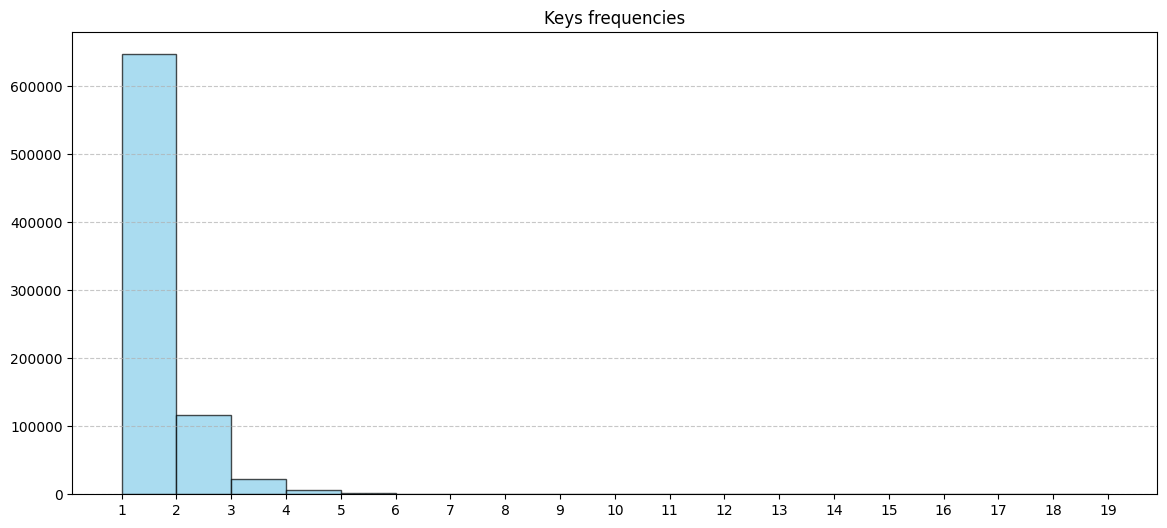

In [5]:
utils.print_by_buckets(keys=list(keys_frequencies.values()),
                       num_buckets=40,
                       title="Keys frequencies")

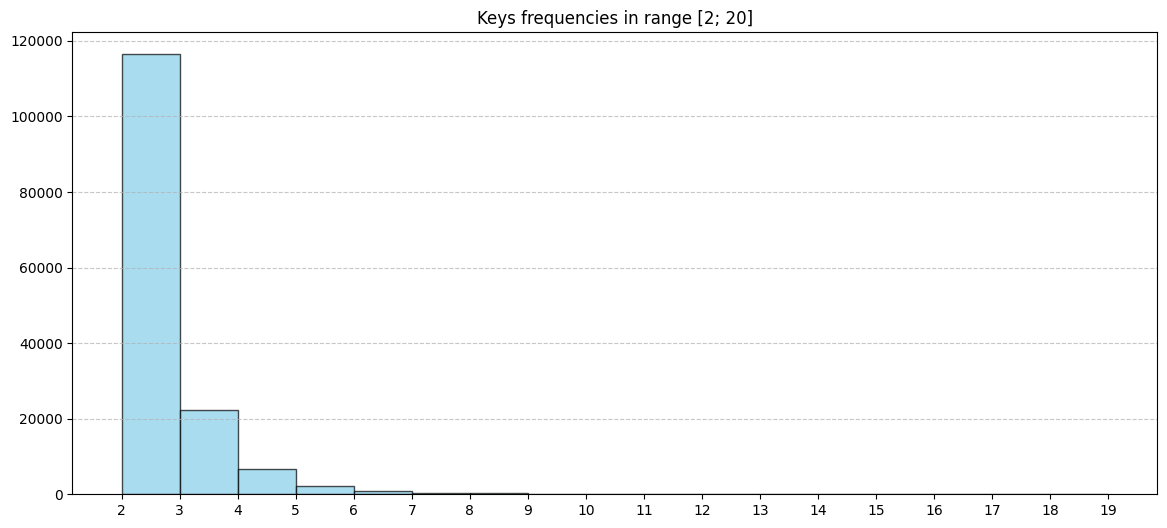

In [6]:
utils.print_by_buckets(keys=[f for f in (list(keys_frequencies.values())) if 2 <= f <= 20],
                       num_buckets=20,
                       title="Keys frequencies in range [2; 20]")

In [7]:
keys_timings = utils.get_key_inter_reference_stats(keys=keys)
keys_timings_only = []
for k, v in keys_timings.items():
    keys_timings_only.extend(v)


keys_timings2 = utils.get_key_inter_reference_stats2(keys=keys)
keys_timings2_only = []
for k, v in keys_timings2.items():
    keys_timings2_only.extend(v)

# Inter-reference time array statistics:

In [8]:
print("Time distance sequence:")
utils.print_sequence_stat(values=keys_timings_only)

print("\nUnique requests distance sequence:")
utils.print_sequence_stat(values=keys_timings2_only)

Time distance sequence:
Max: 954891
Min: 1
AVG: 26079.69
Median: 13264

Unique requests distance sequence:
Max: 761370
Min: 0
AVG: 22937.97
Median: 12632


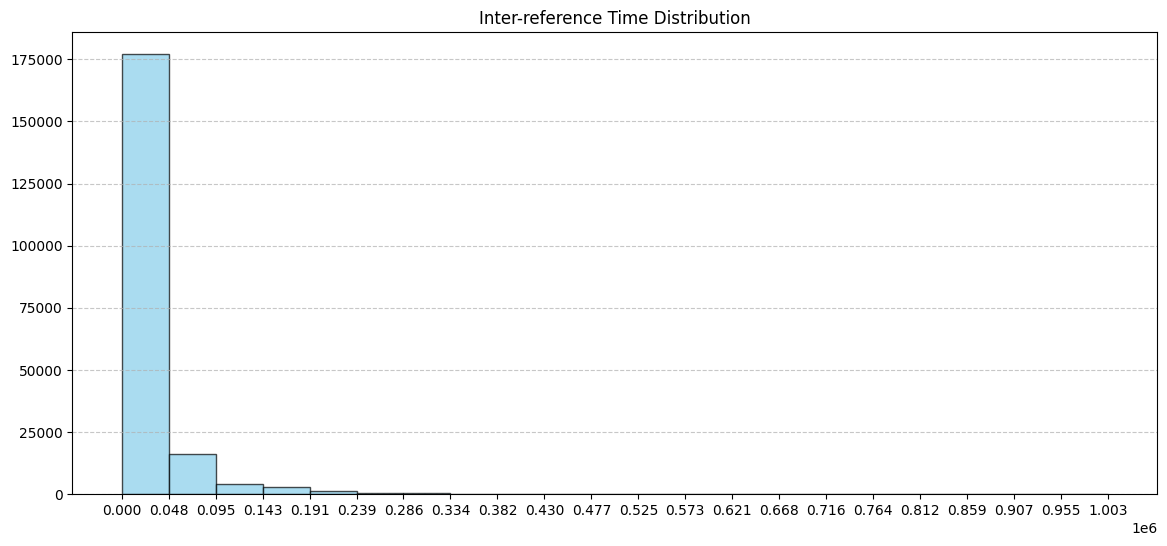

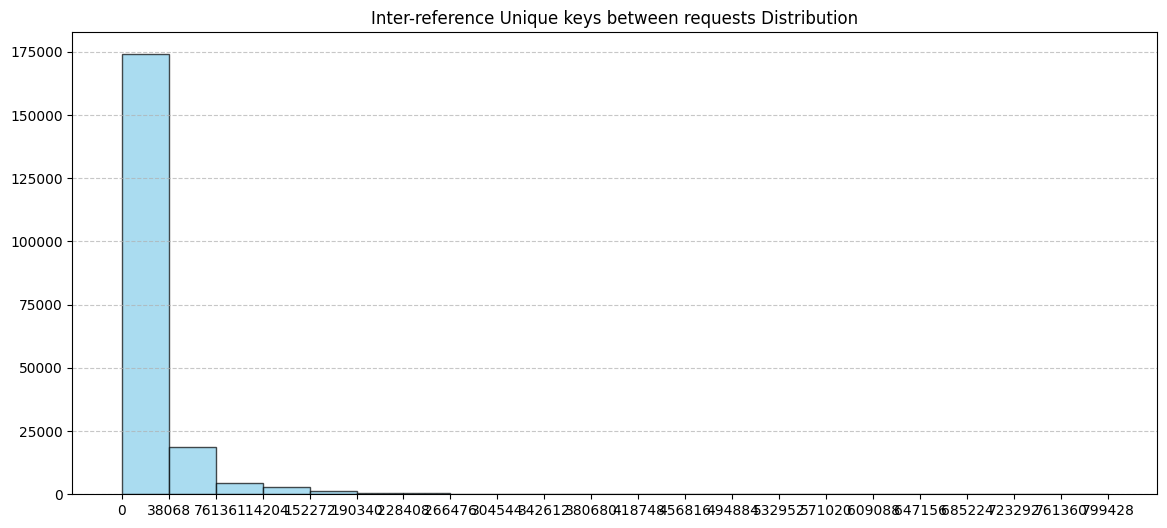

In [9]:
utils.print_by_buckets(keys=keys_timings_only, num_buckets=20, title="Inter-reference Time Distribution")
utils.print_by_buckets(keys=keys_timings2_only, num_buckets=20, title="Inter-reference Unique keys between requests Distribution")

Bad cases: 169519
Good cases: 33480
Accuracy = 0.1649


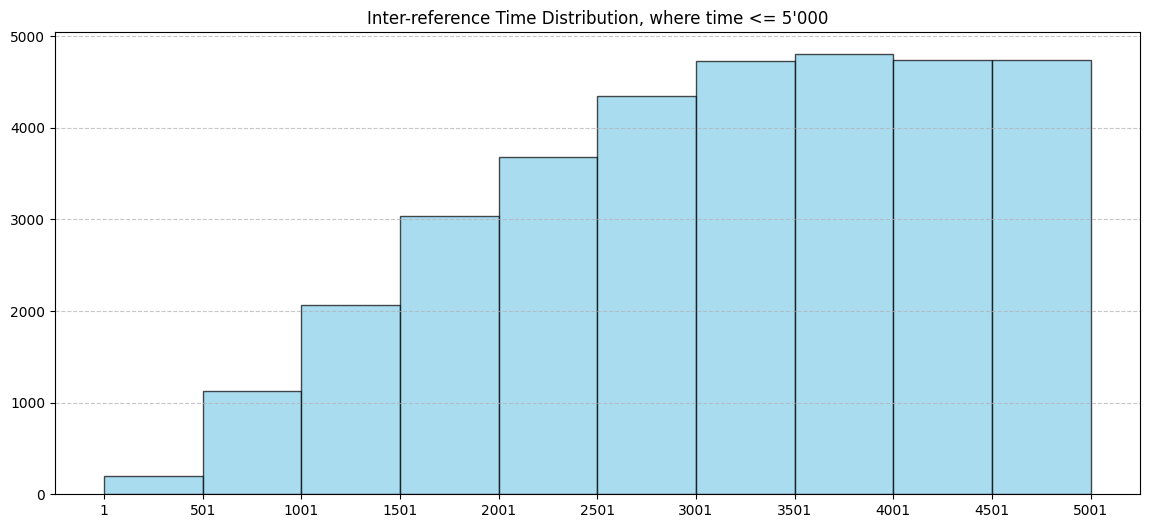

Bad cases: 168917
Good cases: 34082
Accuracy = 0.1679


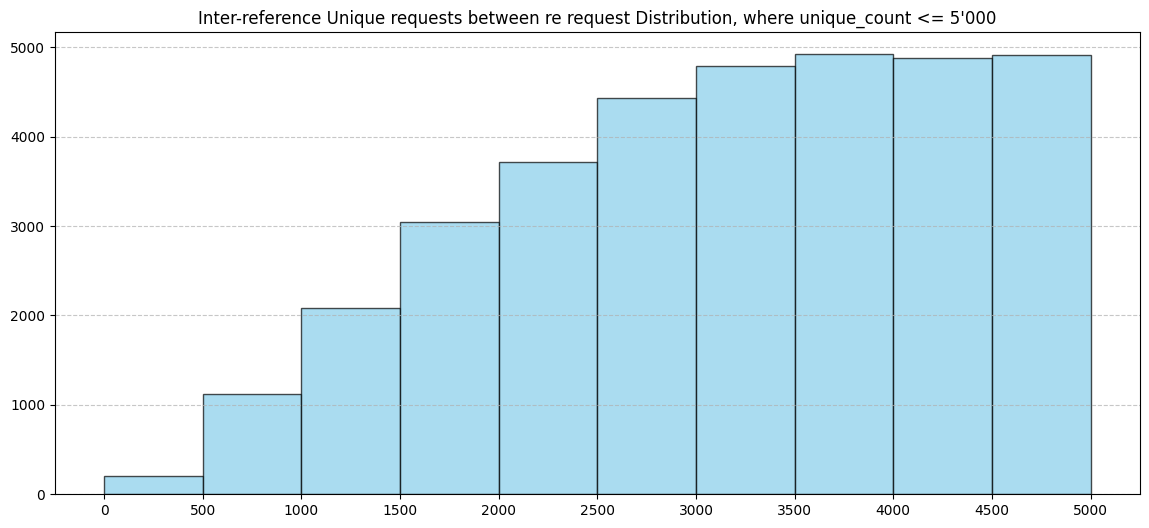

In [10]:
bad_cases  = [t for t in keys_timings_only if t > 5000]
good_cases = [t for t in keys_timings_only if t <= 5000]
print(f"Bad cases: {len(bad_cases)}")
print(f"Good cases: {len(good_cases)}")
print(f"Accuracy = {len(good_cases) / (len(good_cases) + len(bad_cases)):.4f}")
utils.print_by_buckets(keys=good_cases, num_buckets=10, title="Inter-reference Time Distribution, where time <= 5'000")


bad_cases  = [t for t in keys_timings2_only if t > 5000]
good_cases = [t for t in keys_timings2_only if t <= 5000]
print(f"Bad cases: {len(bad_cases)}")
print(f"Good cases: {len(good_cases)}")
print(f"Accuracy = {len(good_cases) / (len(good_cases) + len(bad_cases)):.4f}")
utils.print_by_buckets(keys=good_cases, num_buckets=10, title="Inter-reference Unique requests between re request Distribution, where unique_count <= 5'000")

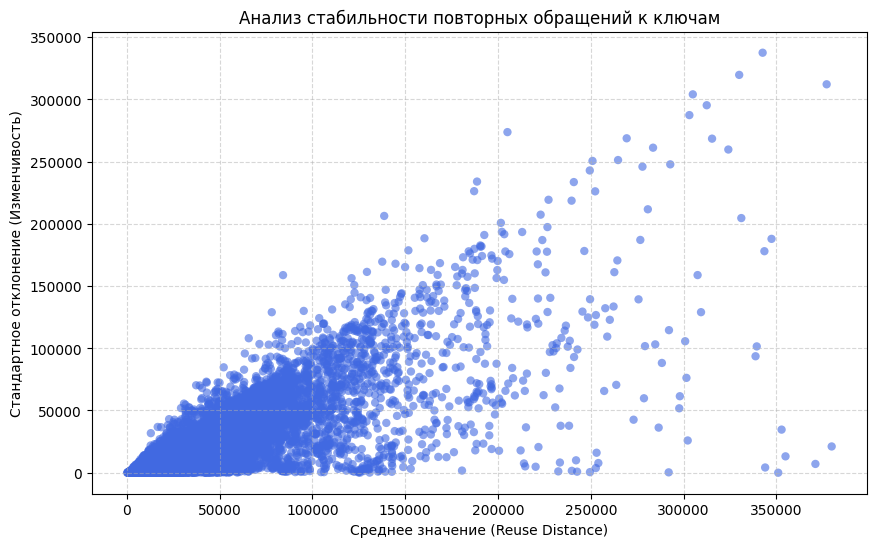

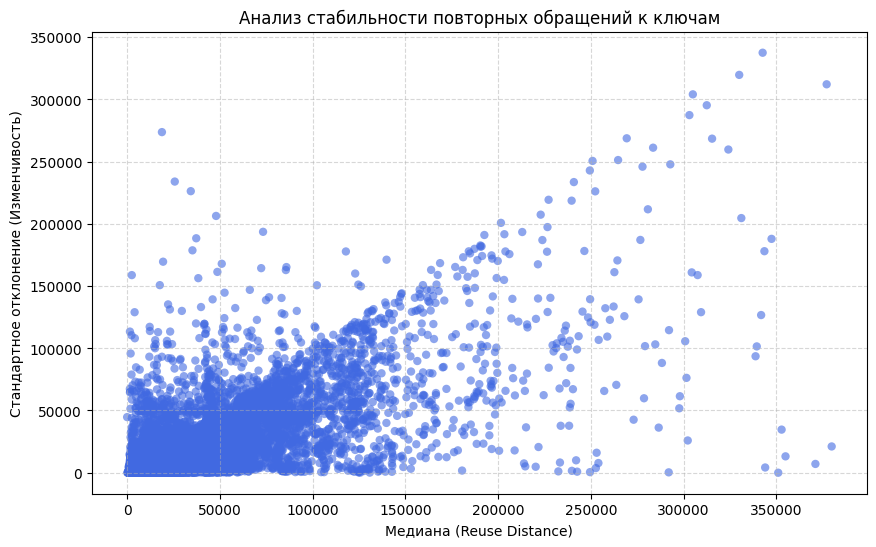

In [11]:
utils.plot_reuse_distance_stability(data=keys_timings2, use_median=False)
utils.plot_reuse_distance_stability(data=keys_timings2, use_median=True)

Всего повторных обращений: 202999
Обращений в выделенной зоне: 64313
Процент 'теплых' обращений в зоне: 31.68%


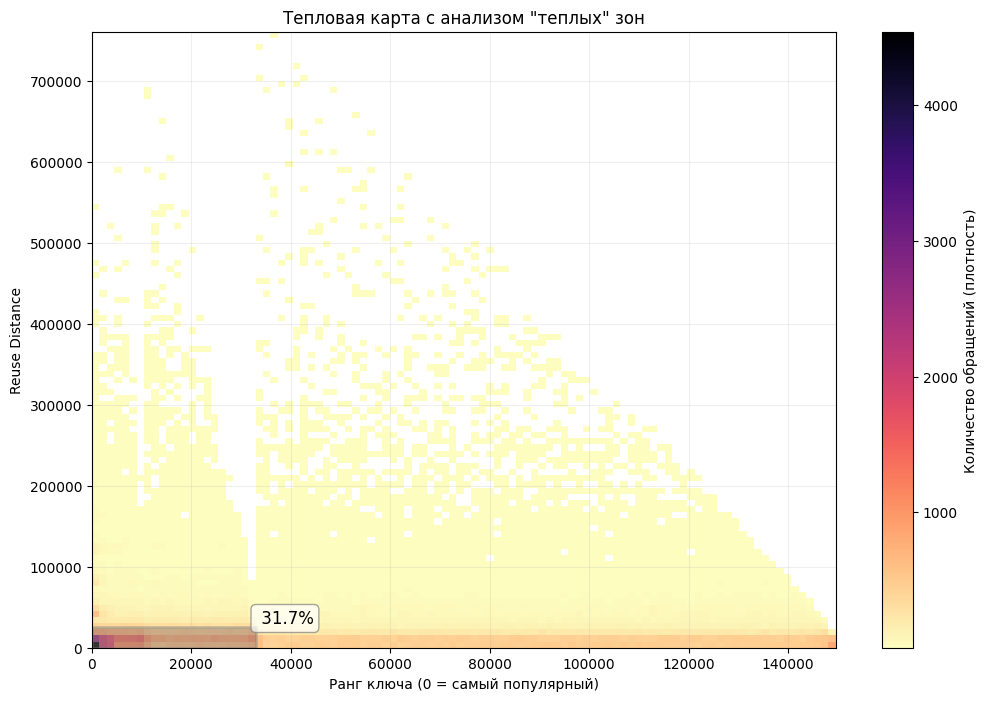

In [34]:
utils.plot_reuse_distance_heatmap_with_rect(data=keys_timings2, keys_sequence=keys, bins=100, rect_x=(0, 33_000), rect_y=(0, 25_000))

Всего повторных обращений: 202999
Обращений в выделенной зоне: 40980
Процент 'теплых' обращений в зоне: 20.19%


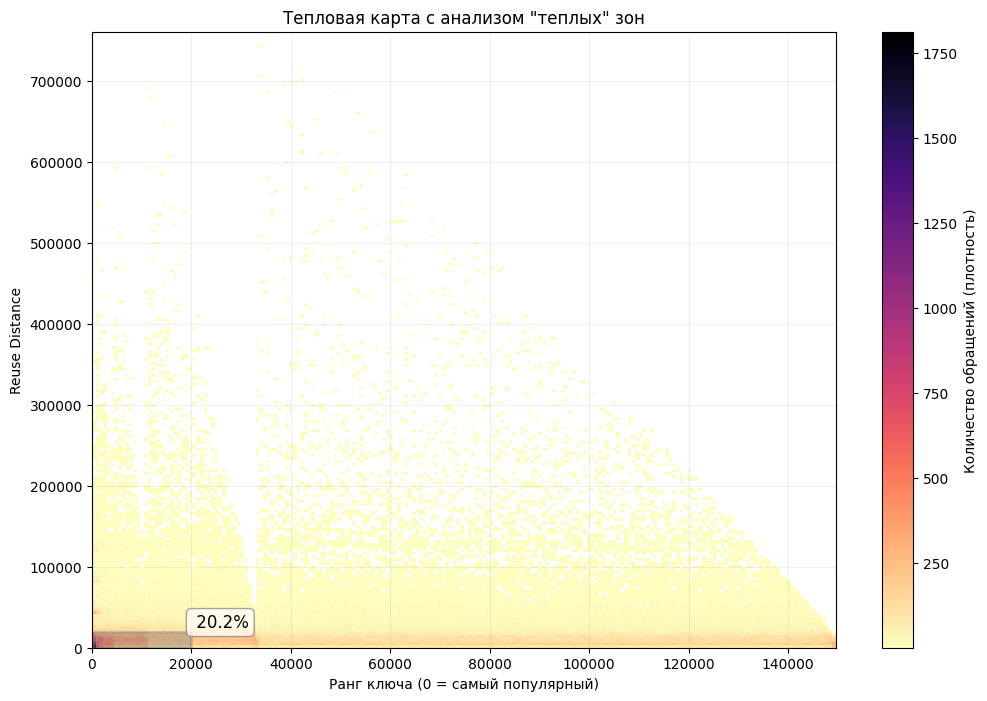

In [36]:
utils.plot_reuse_distance_heatmap_with_rect(data=keys_timings2, keys_sequence=keys, bins=200, rect_x=(0, 20_000), rect_y=(0, 20_000))

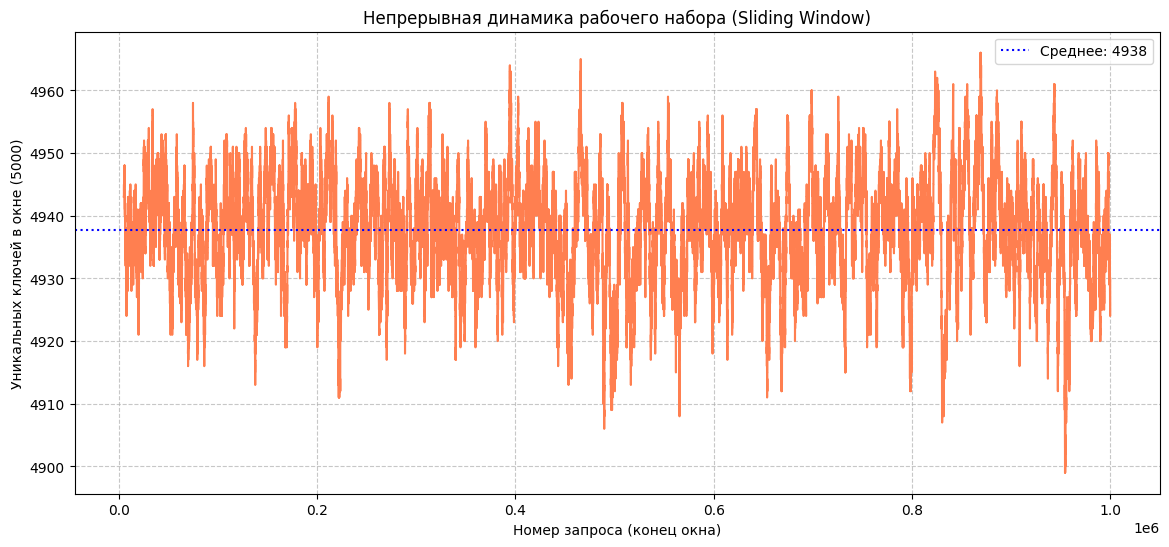

In [37]:
utils.plot_continuous_working_set_size(keys_sequence=keys, window_size=5000)